<a href="https://colab.research.google.com/github/sleepyarya/PCVK-SMT5/blob/main/Modul1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow # Khusus Google Colab
from skimage import io, transform
from PIL import Image
import matplotlib.pylab as plt

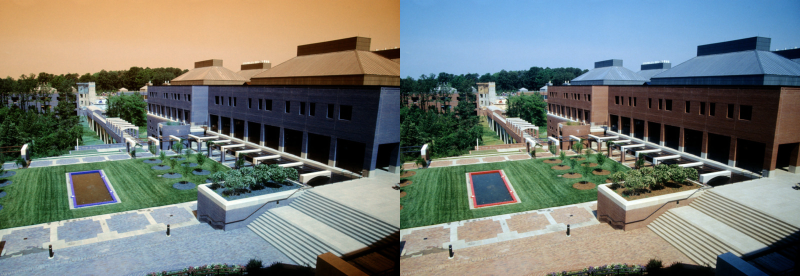

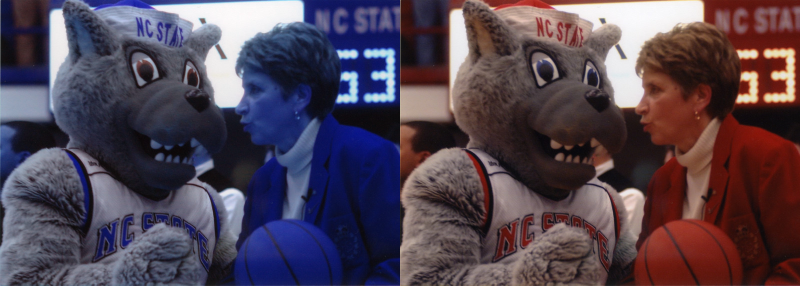



Gagal memuat URL https://placekitten.com/800/571: HTTP Error 521: <none>


In [2]:
# List URL gambar uji
urls = [
    "https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
    "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
    "https://placekitten.com/800/571"
]

# Loop untuk membaca dan menampilkan gambar
for url in urls:
    try:
        image = io.imread(url)
        # Resize gambar menjadi setengah ukuran asli
        image = cv.resize(image, (0, 0), fx=0.5, fy=0.5)
        # Konversi warna dari BGR ke RGB
        image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        # Gabungkan gambar secara horizontal (sebelah-sebelahan)
        final_frame = cv.hconcat((image, image_2))

        # Tampilkan hasil
        cv2_imshow(final_frame)
        print('\n')
    except Exception as e:
        print(f"Gagal memuat URL {url}: {e}")

Resolusi image: tinggi x lebar = 286 x 400


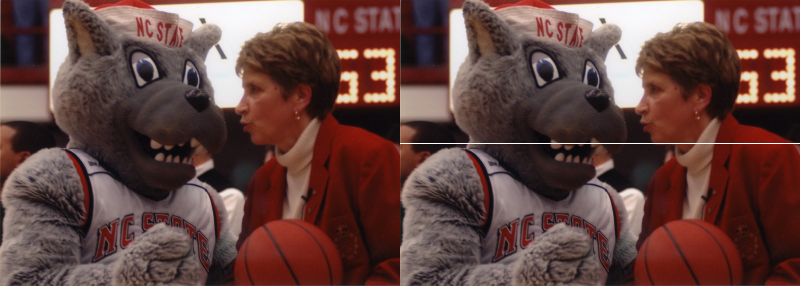

In [3]:
# Modul 1 - Langkah 3 & 4 (Cek Ukuran & Garis Horizontal)

# 1. Ambil URL gambar yang aktif
url_aktif = "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg"
image_raw = io.imread(url_aktif)

# Resize ke setengah ukuran
image = cv.resize(image_raw, (0, 0), fx=0.5, fy=0.5)

# Konversi BGR ke RGB
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# 2. Langkah 3: Cek ukuran/resolusi gambar (Tinggi x Lebar)
tinggi = image_2.shape[0]
lebar = image_2.shape[1]
print("Resolusi image: tinggi x lebar =", tinggi, "x", lebar)

# 3. Langkah 4: Modifikasi pixel (membuat garis horizontal putih di tengah gambar)
for y in range(lebar):
    image_3[int(tinggi / 2), y] = [255, 255, 255] # [R, G, B] warna putih

# Gabungkan dan tampilkan gambar asli vs gambar bergaris
final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

1. Mengapa eksekusi kode dilakukan menggunakan Google Colab?

Google Colab bersifat cloud-based dan gratis, tidak memerlukan instalasi lokal, menyediakan pustaka AI/CV bawaan (NumPy, OpenCV, Matplotlib), serta memberikan akses gratis ke GPU/TPU untuk komputasi cepat.

2. Kegunaan setiap library pada langkah 1 & apakah harus digunakan semua?NumPy: Manipulasi array multidimensi dan matriks piksel.  Pandas: Pengolahan dan analisis data terstruktur.  OpenCV (cv2): Operasi pemrosesan citra dan komputer visi.  scikit-image (skimage): Pembacaan dan transformasi citra.  PIL (Pillow): Pengolahan dan manipulasi format citra.  Matplotlib: Plotting dan visualisasi citra/grafik.  Tidak semua harus dipakai sekaligus; untuk pemrosesan citra dasar sederhana, cukup menggunakan OpenCV, NumPy, dan Matplotlib.

3. Kegunaan cv.resize(image, (0,0), fx=0.5, fy=0.5) & pengaruh jika tidak dilakukan:Kode ini mengecilkan ukuran citra sebesar 50% ($0.5$) pada sumbu $x$ dan $y$. Jika tidak dilakukan, ukuran gambar tetap pada resolusi aslinya yang bisa memakan memori lebih besar dan tampilan visual di layar akan terlalu luas/besar

4. Kegunaan kode [255, 255, 255]:

Merupakan nilai warna dalam format RGB (Red=255, Green=255, Blue=255) yang menghasilkan warna putih maksimal. Kode tersebut menetapkan piksel pada koordinat tertentu menjadi berwarna putih.

5. Keterkaitan pixel dan resolusi gambar:Resolusi adalah jumlah total piksel (lebar $\times$ tinggi) yang menyusun citra. Makin tinggi resolusi, makin banyak jumlah pikselnya sehingga detail gambar makin tajam dan halus. Sebaliknya, resolusi rendah memiliki piksel lebih sedikit sehingga gambar tampak buram atau pecah (pecah-pecah/kotak-kotak)

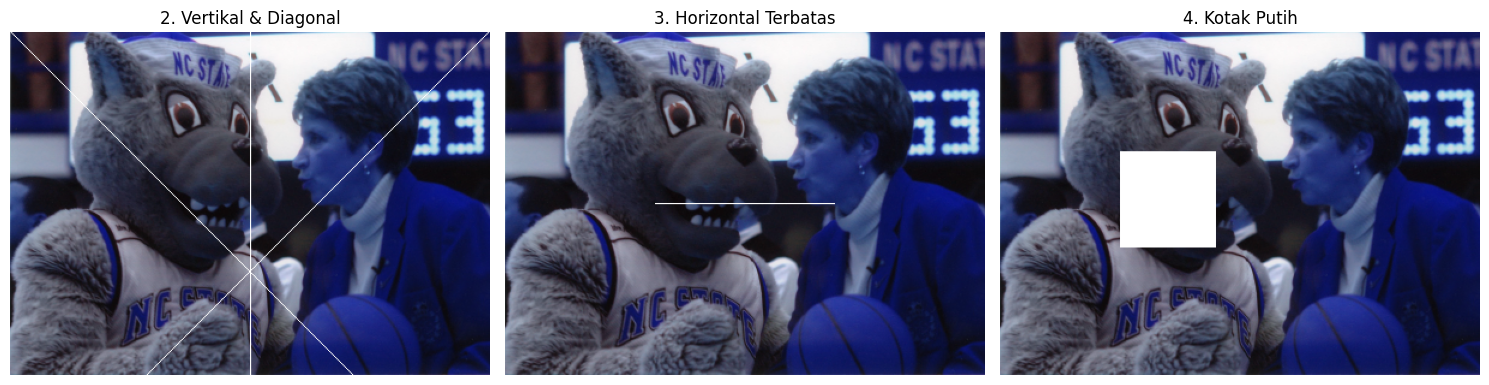

In [4]:
# TUGAS PRAKTIKUM D2 (Nomor 2, 3, dan 4)

url_aktif = "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg"
image_raw = io.imread(url_aktif)

# Resize & Konversi ke RGB
image_base = cv.resize(image_raw, (0, 0), fx=0.5, fy=0.5)
image_rgb = cv.cvtColor(image_base, cv.COLOR_BGR2RGB)

tinggi, lebar = image_rgb.shape[:2]

# --- 2. Garis Vertikal & Garis Menyilang Diagonal ---
img_task2 = image_rgb.copy()

# Garis vertikal di tengah
for x in range(tinggi):
    img_task2[x, int(lebar / 2)] = [255, 255, 255]

# Garis diagonal 1 (kiri atas ke kanan bawah) & 2 (kanan atas ke kiri bawah)
for i in range(min(tinggi, lebar)):
    img_task2[i, i] = [255, 255, 255]
    img_task2[i, lebar - 1 - i] = [255, 255, 255]

# --- 3. Garis Horizontal Putih dengan Panjang Tertentu (di tengah) ---
img_task3 = image_rgb.copy()
panjang_garis = 150  # Panjang garis dalam pixel
start_x = (lebar - panjang_garis) // 2
end_x = start_x + panjang_garis

for y in range(start_x, end_x):
    img_task3[int(tinggi / 2), y] = [255, 255, 255]

# --- 4. Kotak Piksel Warna Putih di Sembarang Tempat ---
img_task4 = image_rgb.copy()
# Membuat blok putih ukuran 80x80 piksel di koordinat (y: 100-180, x: 100-180)
img_task4[100:180, 100:180] = [255, 255, 255]

# Tampilkan ketiga hasil tugas berdampingan
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_task2)
plt.title("2. Vertikal & Diagonal")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_task3)
plt.title("3. Horizontal Terbatas")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_task4)
plt.title("4. Kotak Putih")
plt.axis("off")

plt.tight_layout()
plt.show()

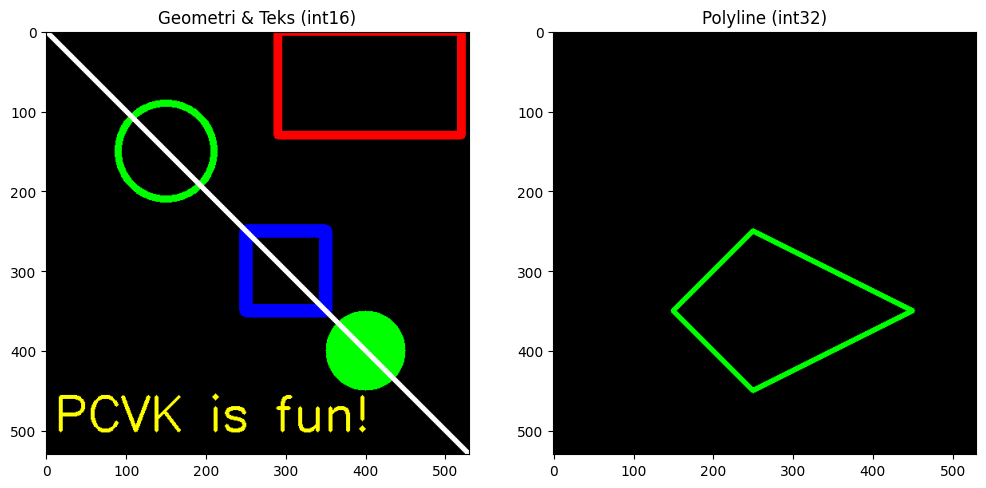

In [5]:
# Modul 2 (D3) - Pembuatan Bentuk Geometri 2D & Teks

# 1. Buat kanvas hitam berukuran 530x530 piksel (tipe data int16)
black_img = np.zeros(shape=(530, 530, 3), dtype=np.int16)

# 2. Gambar Persegi Panjang Merah & Persegi Biru
cv.rectangle(black_img, pt1=(290, 0), pt2=(520, 130), color=(255, 0, 0), thickness=10) # BGR -> Red
cv.rectangle(black_img, pt1=(250, 250), pt2=(350, 350), color=(0, 0, 255), thickness=15) # BGR -> Blue

# 3. Gambar Lingkaran Hijau, Lingkaran Padat, dan Garis
cv.circle(black_img, center=(150, 150), radius=60, color=(0, 255, 0), thickness=8)
cv.circle(black_img, center=(400, 400), radius=50, color=(0, 255, 0), thickness=-1) # -1 untuk isi penuh
cv.line(black_img, pt1=(0, 0), pt2=(530, 530), color=(255, 255, 255), thickness=5)

# 4. Tambahkan Teks
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='PCVK is fun!', org=(10, 500), fontFace=font, fontScale=2, color=(255, 255, 0), thickness=3, lineType=cv.LINE_AA)

# 5. Buat Polyline (Poligon 4 Titik) pada Kanvas int32
black_img2 = np.zeros(shape=(530, 530, 3), dtype=np.int32)
vertices = np.array([[150, 350], [250, 250], [450, 350], [250, 450]], dtype=np.int32)
pts = vertices.reshape((-1, 1, 2))
cv.polylines(black_img2, [pts], isClosed=True, color=(0, 255, 0), thickness=5)

# Tampilkan kedua kanvas
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(black_img)
plt.title("Geometri & Teks (int16)")

plt.subplot(1, 2, 2)
plt.imshow(black_img2)
plt.title("Polyline (int32)")

plt.show()

1. Perbedaan gambar yang ditampilkan tanpa dan dengan matplotlib:Tanpa Matplotlib (menggunakan cv2_imshow), citra ditampilkan langsung dalam bentuk array raw dengan skala warna BGR. Sedangkan dengan Matplotlib (plt.imshow), citra dilengkapi dengan sumbu koordinat (koordinat piksel $x$ dan $y$) serta memerlukan konversi BGR ke RGB agar warnanya tidak tertukar.

2. Perbedaan dan pengaruh pembuatan black image antara tipe data int16 dan int32:int16: Memakan memori 2 byte per elemen dengan rentang nilai $-32.768$ hingga $32.767$.  int32: Memakan memori 4 byte per elemen dengan rentang nilai $-2.147.483.648$ hingga $2.147.483.647$.  Pengaruh: Secara visual tampilannya sama-sama hitam. Namun, tipe int32 wajib digunakan saat menggambar bentuk kompleks seperti cv2.polylines() agar larik koordinat titik piksel tidak overflow.

3. Kegunaan from google.colab.patches import cv2_imshow:

Digunakan untuk menggantikan fungsi bawaan cv2.imshow() milik OpenCV yang tidak bisa berjalan di Google Colab karena keterbatasan sistem antarmuka (GUI) berbasis browser.

4. Kegunaan from skimage import io:

Digunakan untuk mengimpor modul I/O dari pustaka scikit-image yang berfungsi membaca (io.imread) dan menyimpan citra dari URL web maupun direktori lokal.

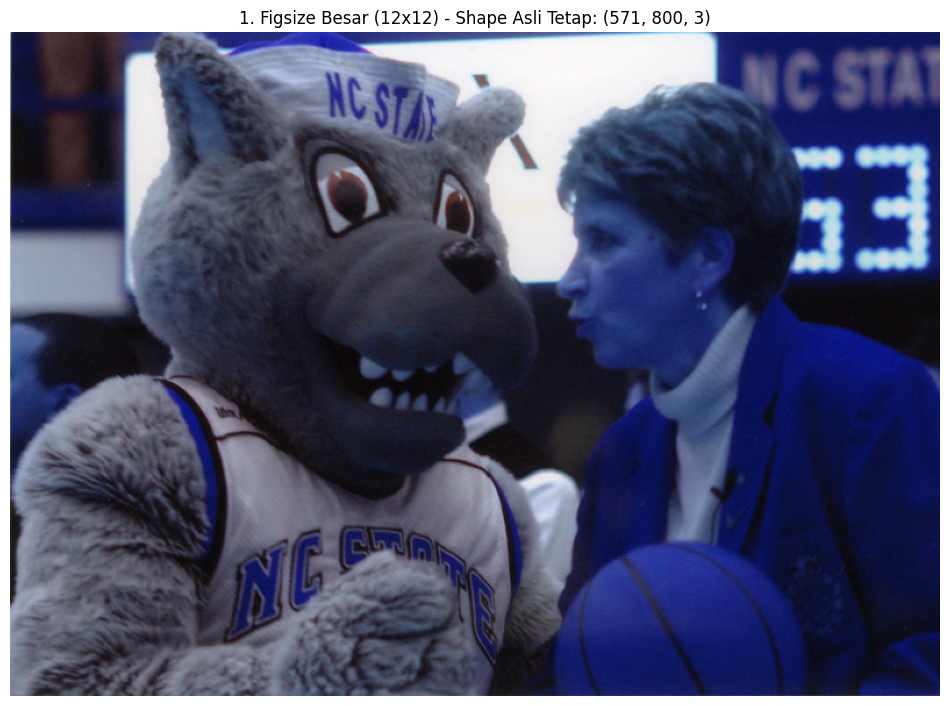

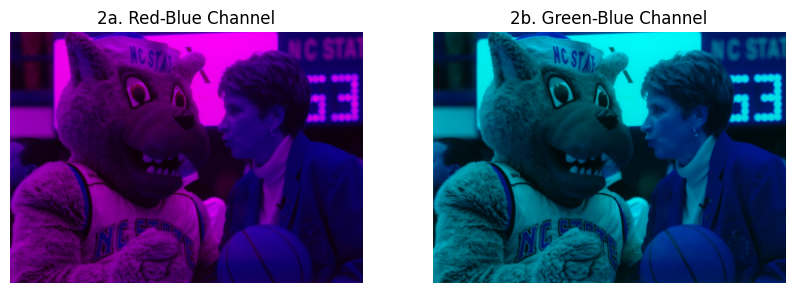

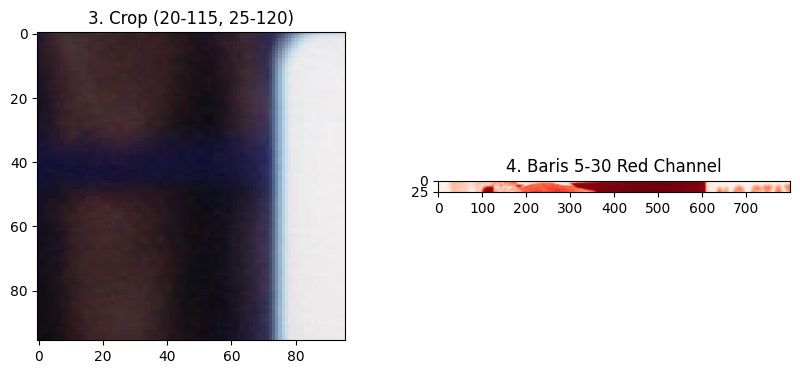

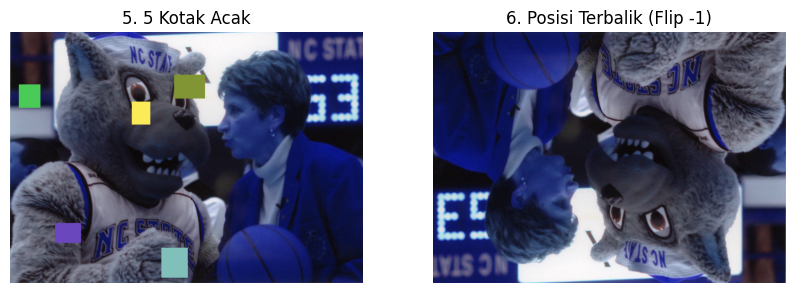

In [6]:
# TUGAS PRAKTIKUM D3 (Nomor 1 - 6)

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from skimage import io

# Ambil gambar dasar
url_aktif = "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg"
img_raw = io.imread(url_aktif)
img_rgb = cv.cvtColor(img_raw, cv.COLOR_BGR2RGB)

# --- 1. Demonstrasi figsize vs img.shape ---
plt.figure(figsize=(12, 12))
plt.imshow(img_rgb)
plt.title(f"1. Figsize Besar (12x12) - Shape Asli Tetap: {img_rgb.shape}")
plt.axis("off")
plt.show()

# --- 2. Channel Red-Blue & Green-Blue ---
img_rb = img_rgb.copy()
img_rb[:, :, 1] = 0  # Green = 0

img_gb = img_rgb.copy()
img_gb[:, :, 0] = 0  # Red = 0

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_rb)
plt.title("2a. Red-Blue Channel")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_gb)
plt.title("2b. Green-Blue Channel")
plt.axis("off")
plt.show()

# --- 3. Slicing Baris 20-115, Kolom 25-120 ---
crop1 = img_rgb[20:116, 25:121]

# --- 4. Slicing Baris 5-30, Semua Kolom, Red Channel Only ---
crop2_red = img_rgb[5:31, :, 0]

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(crop1)
plt.title("3. Crop (20-115, 25-120)")

plt.subplot(1, 2, 2)
plt.imshow(crop2_red, cmap='Reds')
plt.title("4. Baris 5-30 Red Channel")
plt.show()

# --- 5. 5 Kotak Acak (Random) ---
img_5box = img_rgb.copy()
h, w, _ = img_5box.shape
np.random.seed(42)  # Konsistensi warna/posisi acak

for _ in range(5):
    pt1 = (np.random.randint(0, w - 50), np.random.randint(0, h - 50))
    pt2 = (pt1[0] + np.random.randint(30, 80), pt1[1] + np.random.randint(30, 80))
    color = tuple(map(int, np.random.randint(0, 256, size=3)))
    cv.rectangle(img_5box, pt1, pt2, color, thickness=-1)

# --- 6. Gambar Posisi Terbalik (Flip Vertical & Horizontal) ---
img_flip = cv.flip(img_rgb, -1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_5box)
plt.title("5. 5 Kotak Acak")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_flip)
plt.title("6. Posisi Terbalik (Flip -1)")
plt.axis("off")
plt.show()

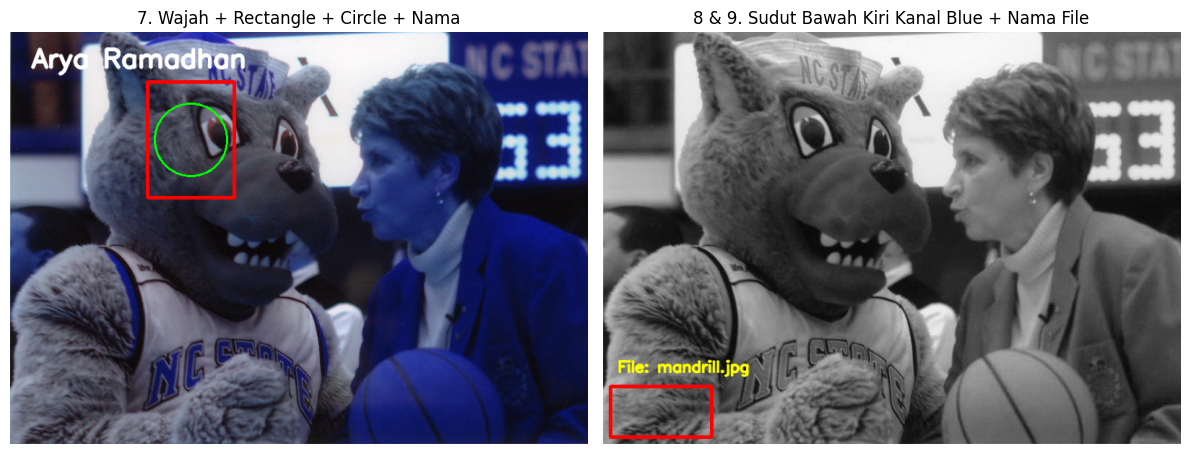

In [7]:
# TUGAS PRAKTIKUM D3 (Nomor 7, 8, dan 9)

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from skimage import io

# Ambil gambar uji dari URL
url_aktif = "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg"
img_raw = io.imread(url_aktif)
img_rgb = cv.cvtColor(img_raw, cv.COLOR_BGR2RGB)

# --- 7. Rectangle & Circle pada bagian Wajah/Badan Foto + Teks Nama ---
img_task7 = img_rgb.copy()

# Koordinat area wajah (disesuaikan dengan posisi wajah pada gambar)
# Gambar Persegi Panjang Merah di sekitar area wajah
cv.rectangle(img_task7, pt1=(190, 70), pt2=(310, 230), color=(255, 0, 0), thickness=3)

# Gambar Lingkaran Hijau tepat di area muka
cv.circle(img_task7, center=(250, 150), radius=50, color=(0, 255, 0), thickness=2)

# Tambahkan Teks Nama
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(img_task7, text='Arya Ramadhan', org=(30, 50),
           fontFace=font, fontScale=1.2, color=(255, 255, 255), thickness=3, lineType=cv.LINE_AA)

# --- 8 & 9. Rectangle pada Sudut Bawah Kiri Kanal B + Teks Nama File ---
# Ekstrak Kanal Blue (Blue Space/Blue Channel)
img_blue = img_rgb[:, :, 2] # Indeks 2 untuk Kanal Blue

# Ubah ke 3-channel BGR/RGB agar garis warna & teks bisa terlihat jelas
img_task8 = cv.cvtColor(img_blue, cv.COLOR_GRAY2RGB)

h, w = img_task8.shape[:2]

# Gambar Rectangle di Sudut Bawah Kiri (Left-Bottom Corner)
cv.rectangle(img_task8, pt1=(10, h - 80), pt2=(150, h - 10), color=(255, 0, 0), thickness=3)

# Tambahkan Teks Nama File Citra (Nomor 9)
cv.putText(img_task8, text='File: mandrill.jpg', org=(20, h - 100),
           fontFace=font, fontScale=0.7, color=(255, 255, 0), thickness=2, lineType=cv.LINE_AA)

# Tampilkan Hasil Tugas 7, 8, & 9
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_task7)
plt.title("7. Wajah + Rectangle + Circle + Nama")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_task8)
plt.title("8 & 9. Sudut Bawah Kiri Kanal Blue + Nama File")
plt.axis("off")

plt.tight_layout()
plt.show()